# Stacking 算法实战：Iris 数据集多分类

本案例演示如何使用 Stacking 集成学习方法处理 Iris（鸢尾花）多分类问题。我们将结合 K 近邻（KNN）、随机森林（Random Forest）和朴素贝叶斯（Naive Bayes）作为基学习器，并使用逻辑回归（Logistic Regression）作为元学习器，以此构建一个强分类器。

## 1. 导入必要的库

首先，我们需要导入数据处理、模型构建以及评估可视化所需的 Python 库。

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.classifier import StackingClassifier
from mlxtend.plotting import plot_decision_regions

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 数据加载与预处理

加载 Iris 数据集，并将其划分为训练集和测试集（80% 训练，20% 测试）。

In [10]:
# 加载 iris 数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"特征维度: {X.shape[1]}")
print(f"训练集样本数: {X_train.shape[0]}")
print(f"测试集样本数: {X_test.shape[0]}")

特征维度: 4
训练集样本数: 120
测试集样本数: 30


## 3. 构建 Stacking 集成模型

我们定义三个基学习器：
1.  **K 近邻 (KNN)**
2.  **随机森林 (Random Forest)**
3.  **朴素贝叶斯 (Naive Bayes)**

元学习器采用 **逻辑回归 (Logistic Regression)**。

In [11]:
# 定义基学习器
clf1 = KNeighborsClassifier(n_neighbors=3)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = GaussianNB()

# 定义元学习器
lr = LogisticRegression(solver='lbfgs', multi_class='auto', random_state=42)

# 创建 Stacking 分类器
sclf = StackingClassifier(classifiers=[clf1, clf2, clf3], meta_classifier=lr)

# 定义分类器列表，方便后续遍历评估
classifiers = [
    ('KNN', clf1),
    ('随机森林', clf2),
    ('朴素贝叶斯', clf3),
    ('Stacking 集成模型', sclf)
]

## 4. 模型训练与评估

我们将分别训练每个基学习器和 Stacking 模型，并计算它们在测试集上的准确率、混淆矩阵以及分类报告。同时，使用 5 折交叉验证来评估模型的稳定性。

In [12]:
print(f"{'模型':<20} {'准确率':<10} {'平均交叉验证准确率':<20}")
print("-" * 60)

for name, clf in classifiers:
    # 训练模型
    clf.fit(X_train, y_train)
    
    # 预测测试集
    y_pred = clf.predict(X_test)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    
    # 交叉验证
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    
    # 输出简要结果
    print(f"{name:<20} {accuracy:.4f}     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # 详细输出
    print(f"\n--- {name} 详细报告 ---")
    print("混淆矩阵:")
    print(confusion_matrix(y_test, y_pred))
    print("\n分类报告:")
    print(classification_report(y_test, y_pred))
    print("=" * 60)

模型                   准确率        平均交叉验证准确率           
------------------------------------------------------------
KNN                  1.0000     0.9583 (+/- 0.0456)

--- KNN 详细报告 ---
混淆矩阵:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

随机森林                 1.0000     0.9417 (+/- 0.0565)

--- 随机森林 详细报告 ---
混淆矩阵:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00   

## 5. 决策边界可视化

为了直观地展示不同模型的分类效果，我们仅选取 Iris 数据集的前两个特征（花萼长度和花萼宽度）进行重新训练和可视化。

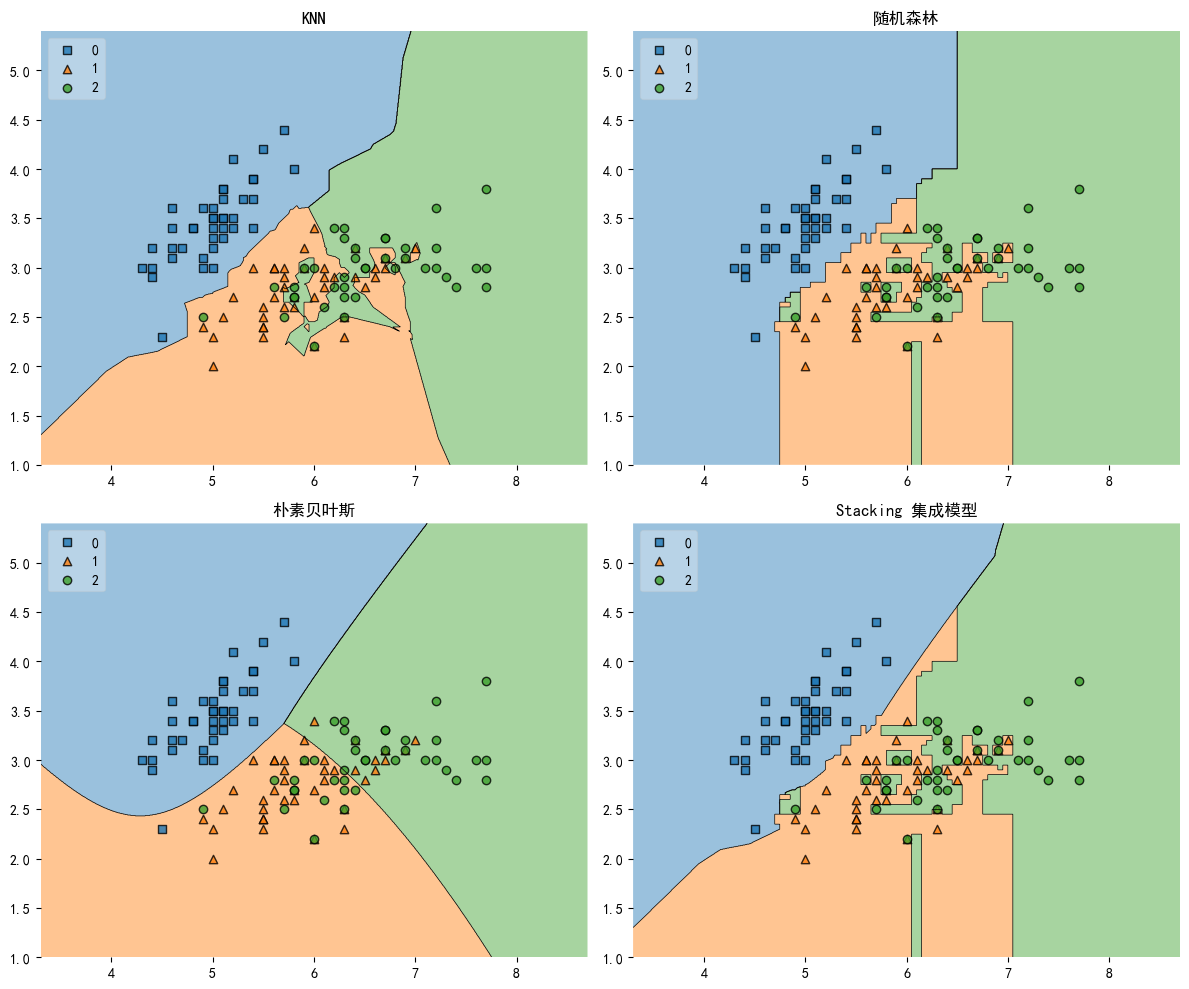

In [13]:
# 可视化决策边界（仅使用前两个特征）
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12, 10))

# 遍历分类器
for clf, lab, grd in zip([clf1, clf2, clf3, sclf], 
                         ['KNN', '随机森林', '朴素贝叶斯', 'Stacking 集成模型'],
                         itertools.product([0, 1], repeat=2)):
    
    # 仅使用前两个特征进行训练
    clf.fit(X_train[:, :2], y_train)
    
    ax = plt.subplot(gs[grd[0], grd[1]])
    
    # 绘制决策区域
    plot_decision_regions(X=X_train[:, :2], y=y_train, clf=clf, legend=2)
    
    plt.title(lab)

plt.tight_layout()
plt.show()

## 6. 总结与分析

通过观察上述决策边界的可视化结果，我们可以得出以下结论：

1.  **K 近邻**(KNN)：决策边界较为曲折、破碎，对局部数据点非常敏感。虽然能很好地拟合训练数据，但容易受到噪声影响。
2.  **随机森林**：决策边界呈阶梯状（矩形划分），这是由决策树的垂直/水平分割特性决定的。它能够很好地处理非线性数据，且具有较好的抗噪能力。
3.  **朴素贝叶斯**：决策边界相对平滑且规则（通常为抛物线型），这是基于其高斯分布假设。它对异常值不太敏感，但在处理复杂非线性边界时可能不如其他模型灵活。
4.  **Stacking 集成模型**：综合了上述基学习器的优势。它的决策边界既保留了对非线性关系的捕捉能力（来自 KNN 和随机森林），又通过元学习器（逻辑回归）的整合变得更加平滑和稳健。这展示了集成学习的核心思想：**博采众长，优势互补**，从而获得比单一模型更好的泛化性能。